## First Implementation of the TFT with only Macro Variables

### Inspecting & Importing Data

In [45]:
import pytorch_forecasting
import warnings
from tqdm import tqdm
warnings.filterwarnings("ignore")
import pandas as pd
import os
import matplotlib.pyplot as plt
import holidays
# different than original example
import lightning.pytorch as pl
import torch
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

In [46]:
# os.getcwd()
monthly_path = '/Users/minna/Code/FS26/AML/aml2026-group-3/data/macro-vars-monthly.csv'
df_monthly = pd.read_csv(monthly_path)
df_monthly = df_monthly.rename(columns = {'Unnamed: 0':'date'})
df_monthly['date'] = pd.to_datetime(df_monthly['date'])
print(df_monthly.tail(10))

           date      CPI    PCEPI    PAYEMS  JTSJOL  UMCSENT    INDPRO
1277 2025-06-01  321.435  126.743  158478.0  7204.0     60.7  101.4785
1278 2025-07-01  322.169  126.960  158542.0  7089.0     61.7  101.8940
1279 2025-08-01  323.291  127.293  158472.0  6919.0     58.2  101.6247
1280 2025-09-01  324.245  127.625  158548.0  7169.0     55.1  101.6680
1281 2025-10-01      NaN  127.871  158408.0  7170.0     53.6  101.2075
1282 2025-11-01  325.063  128.152  158449.0  6846.0     51.0  101.3605
1283 2025-12-01  326.031  128.576  158432.0  6550.0     52.9  101.6781
1284 2026-01-01  326.588  128.965  158592.0  7240.0     56.4  102.3963
1285 2026-02-01  327.460  129.449  158459.0  6882.0     56.6  102.5510
1286 2026-03-01  330.293      NaN  158637.0     NaN      NaN       NaN


In [47]:
# select only the 3 vars with the longest history to avoid NaN issues
df_monthly = df_monthly[["date", "CPI", "PAYEMS", "INDPRO"]]

# drop rows where any core variable is NaN (restricts to common date range)
df_monthly = df_monthly.dropna(subset=["CPI", "PAYEMS", "INDPRO"]).reset_index(drop=True)
print(f"Date range after dropping NAs: {df_monthly['date'].min()} to {df_monthly['date'].max()}, {len(df_monthly)} rows")

Date range after dropping NAs: 1947-01-01 00:00:00 to 2026-02-01 00:00:00, 949 rows


In [48]:
print(df_monthly.info())

<class 'pandas.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    949 non-null    datetime64[us]
 1   CPI     949 non-null    float64       
 2   PAYEMS  949 non-null    float64       
 3   INDPRO  949 non-null    float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 29.8 KB
None


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

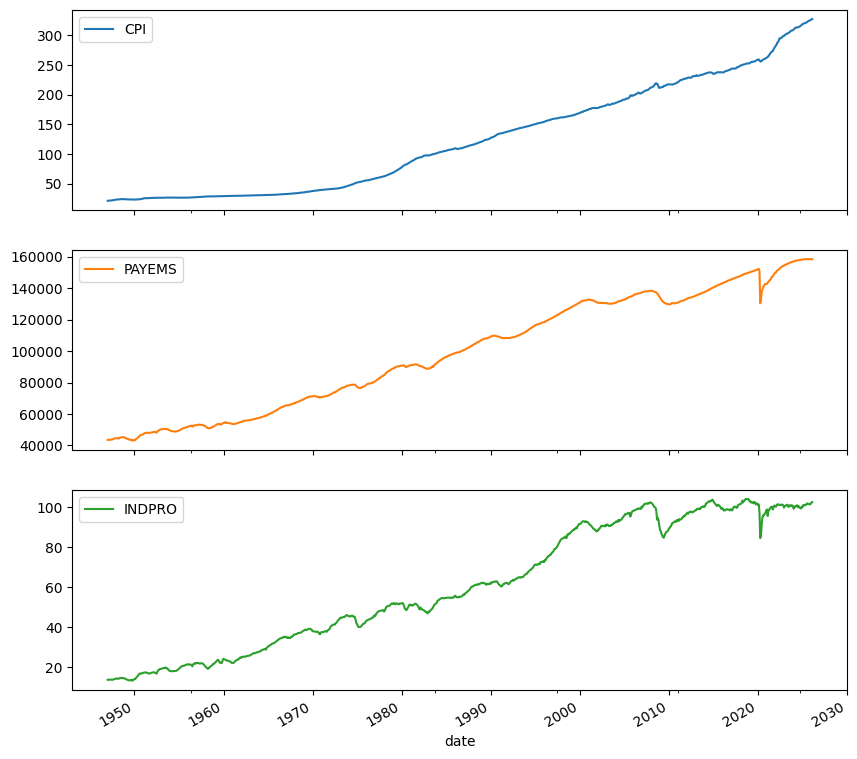

In [49]:
# basic plot to inspect length
df_monthly.plot(x='date', y=['CPI', 'PAYEMS','INDPRO'], subplots=True, figsize=(10, 10))

#### Meaning of Variables:

**CPI** -> Consumer Price Index 
<!-- **PCEPI** -> Personal Consumption Expenditures Price Index  -->
**PAYEMS** -> Total Nonfarm Payrolls
<!-- **JTSJOL** -> Job Openings: Total Nonfarm (non-farm workers)
**UMCSENT** -> University of Michigan Sentiment Index -->
**INDPRO** -> Industrial Production Index

### Implementing TFT

**Info on Model**, based on the following paper: [Temporal Fusion Transformers for Interpretable Multi-horizon Time Series Forecasting](https://arxiv.org/abs/1912.09363)


The TFT should handle single or multiple targets and a whole lot of different covariates such as:

- *static covariates*: these are the ones that do not change through the course of the timeseries. In our case we have country, publication source, etc.  
    - could potentially fetch information from [FRED Website on the different variables](https://fred.stlouisfed.org/series/PAYEMS) for more static covariates? 

- *time series covariates*, they actually belong to 2 different groups:

    - known in advance: such as day_of_the_week, month, holidays, etc.

    - unknown in advance: f.i. if we hade the stock level for each product, we would know it just in the past



In [50]:
# adding time varying known covariates
us_holidays = holidays.US()

df_monthly['day_of_week'] = df_monthly['date'].dt.dayofweek
df_monthly['week_of_year'] = df_monthly['date'].dt.isocalendar().week.astype(int)
df_monthly['month'] = df_monthly['date'].dt.month
df_monthly['is_holiday'] = df_monthly['date'].dt.date.apply(lambda d: int(d in us_holidays))

df_monthly['series_id'] = 'macro'

# precompute lags before train/test split
lag_vars = ["CPI", "PAYEMS", "INDPRO"]
lag_periods = [1, 2, 6, 12]
for col in lag_vars:
    for lag in lag_periods:
        df_monthly[f"{col}_lag_{lag}"] = df_monthly[col].shift(lag)

# drop first 12 rows where lag_12 is undefined
df_monthly = df_monthly.dropna().reset_index(drop=True)

# create time_idx
df_monthly = (df_monthly.merge((df_monthly[['date']].drop_duplicates(ignore_index=True)
.rename_axis('time_idx')).reset_index(), on=['date']))

print(df_monthly.tail(10))
print(f"\nRemaining NAs:\n{df_monthly.isna().sum()[df_monthly.isna().sum() > 0]}")

          date      CPI    PAYEMS    INDPRO  day_of_week  week_of_year  month  \
927 2025-04-01  320.302  158485.0  101.1279            1            14      4   
928 2025-05-01  320.620  158498.0  100.9655            3            18      5   
929 2025-06-01  321.435  158478.0  101.4785            6            22      6   
930 2025-07-01  322.169  158542.0  101.8940            1            27      7   
931 2025-08-01  323.291  158472.0  101.6247            4            31      8   
932 2025-09-01  324.245  158548.0  101.6680            0            36      9   
933 2025-11-01  325.063  158449.0  101.3605            5            44     11   
934 2025-12-01  326.031  158432.0  101.6781            0            49     12   
935 2026-01-01  326.588  158592.0  102.3963            3             1      1   
936 2026-02-01  327.460  158459.0  102.5510            6             5      2   

     is_holiday series_id  CPI_lag_1  ...  CPI_lag_12  PAYEMS_lag_1  \
927           0     macro    319.785 

In [51]:
# split into test, train
tr_len = round(len(df_monthly) * 0.8)

train = df_monthly.iloc[:tr_len]
test = df_monthly.iloc[tr_len:]
print(train.tail()) # goes until 2004

          date      CPI    PAYEMS   INDPRO  day_of_week  week_of_year  month  \
745 2010-02-01  217.281  129706.0  89.6779            0             5      2   
746 2010-03-01  217.353  129866.0  90.2928            0             9      3   
747 2010-04-01  217.403  130120.0  90.5991            3            13      4   
748 2010-05-01  217.290  130642.0  91.8230            5            17      5   
749 2010-06-01  217.199  130510.0  91.9928            1            22      6   

     is_holiday series_id  CPI_lag_1  ...  CPI_lag_12  PAYEMS_lag_1  \
745           0     macro    217.488  ...     212.705      129802.0   
746           0     macro    217.281  ...     212.495      129706.0   
747           0     macro    217.353  ...     212.709      129866.0   
748           0     macro    217.403  ...     213.022      130120.0   
749           0     macro    217.290  ...     214.790      130642.0   

     PAYEMS_lag_2  PAYEMS_lag_6  PAYEMS_lag_12  INDPRO_lag_1  INDPRO_lag_2  \
745      12980

In [52]:
max_encoder_length = 24  # 2 years lookback
max_prediction_length = 12  # 12 months forecast

lag_vars = ["CPI", "PAYEMS", "INDPRO"]
lag_periods = [1, 2, 6, 12]
lagged_cols = [f"{col}_lag_{lag}" for col in lag_vars for lag in lag_periods]

training = TimeSeriesDataSet(
    data=train,
    time_idx="time_idx",
    target="INDPRO",
    group_ids=["series_id"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["series_id"],
    static_reals=[],
    time_varying_known_reals=["time_idx", "day_of_week", "week_of_year", "month", "is_holiday"],
    time_varying_known_categoricals=[],
    time_varying_unknown_reals=["CPI", "PAYEMS", "INDPRO"] + lagged_cols,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, train, predict=True, stop_randomization=True)

batch_size = 128
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

In [53]:
# naive model 
actuals = torch.cat([y for x, (y, weight) in iter(val_dataloader)])
baseline_predictions = Baseline().predict(val_dataloader)
(actuals - baseline_predictions).abs().mean().item()

sm = SMAPE()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


In [54]:
print(f"Median loss for naive prediction on validation: {sm.loss(actuals, baseline_predictions).mean(axis = 1).median().item()}")

Median loss for naive prediction on validation: 0.04828646406531334


### Training and Evaluating TFT

In [55]:
PATIENCE = 30
MAX_EPOCHS = 120
LEARNING_RATE = 0.03
OPTUNA = False # hyperparam opt

In [56]:
from lightning.pytorch.callbacks.progress import TQDMProgressBar

early_stop_callback = EarlyStopping(monitor="train_loss", min_delta=1e-2, patience=PATIENCE, verbose=False, mode="min")
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",  # uses MPS on Apple Silicon, CPU otherwise
    devices=1,
    enable_model_summary=True,
    gradient_clip_val=0.25,
    limit_train_batches=10,
    callbacks=[lr_logger, early_stop_callback, TQDMProgressBar(refresh_rate=1)],
    logger=logger,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=LEARNING_RATE,
    lstm_layers=2,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.2,
    hidden_continuous_size=8,
    output_size=1,  # 7 quantiles by default
    loss=SMAPE(),
    log_interval=10,
    reduce_on_plateau_patience=4
)

tft.to(DEVICE)
print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 38.8k


In [57]:
# add tqdm for progress report
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ SMAPE                           │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    384 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 15.1 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.7 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     17 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 38.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 38.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 606                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 41: 100%|██████████| 5/5 [00:02<00:00,  2.06it/s, v_num=3, train_loss_step=0.0278, val_loss=0.172, train_loss_epoch=0.0333]


In [58]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
predictions = best_tft.predict(val_dataloader, mode="prediction")
# print(predictions[:10])
# print(predictions.shape)

raw_output = best_tft.predict(val_dataloader, mode="raw", return_x=True)
# this is how to unpack it 
raw_predictions = raw_output.output
x = raw_output.x

sm = SMAPE()
print(f"Validation median SMAPE loss: {sm.loss(actuals, predictions).mean(axis=1).median().item()}")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with th

Validation median SMAPE loss: 0.1717720627784729


To compare, the **Median Loss of the Naive model**: 0.02498975209891796

TODO: add ARIMA into this, to compare

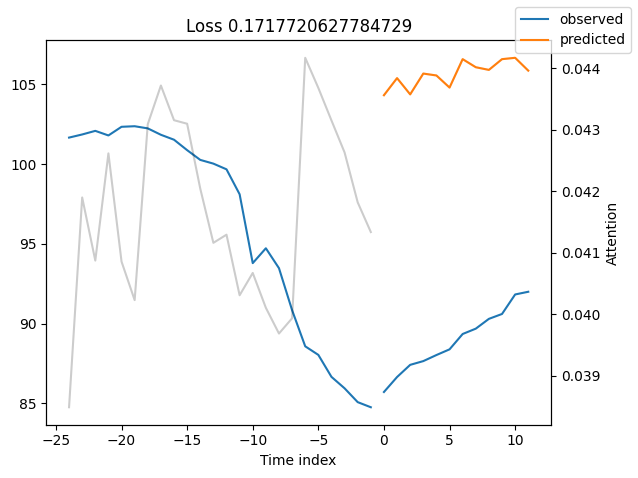

In [59]:
for idx in range(raw_predictions.prediction.shape[0]):
    best_tft.plot_prediction(x, raw_predictions, idx=idx, add_loss_to_title=True);

In [60]:
# predictions, x = best_tft.predict(val_dataloader, return_x=True)
# raw_output = best_tft.predict(val_dataloader, return_x=True)
# # this is how to unpack it 
# predictions = best_tft.predict(val_dataloader, mode="prediction")
# raw_predictions = raw_output.output
# x = raw_output.x
# # diffference predictions vs raw_predictions??
# predictions_vs_actuals = best_tft.calculate_prediction_actual_by_variable(x, predictions)
# all_features = list(set(predictions_vs_actuals['support'].keys())-set(['INDPRO_lag_1', 'INDPRO_lag_2','INDPRO_lag_6', 'INDPRO', 'INDPRO_lag_12', 'INDPRO_scale']))
# print(all_features)
# for feature in all_features:
#     best_tft.plot_prediction_actual_by_variable(predictions_vs_actuals, name=feature);

# useless tbh